# 2. Reserva del conjunto de prueba (partición por bloques espaciales)

*Autores: María Carolina Cantillo Orozco (200179105) y Juan Camilo Oñoro Araujo (200177329)*

Las instrucciones del proyecto exigen **reservar el conjunto de prueba antes de tomar cualquier
decisión basada en los datos** (imputación, transformaciones, selección de
variables, umbrales de outliers) y que la partición respete la estructura de
los datos. Aquí hay tres estructuras que respetar a la vez:

| Estructura | Riesgo si se ignora | Respuesta |
|---|---|---|
| Desbalance de clases (~8:1 entre estrato 1 y estrato 6 en el dataset limpio, cap. 1) | un fold sin casos de estrato 5 o 6 | **estratificar** |
| Varias filas por entidad (apartamentos de un mismo edificio, casi idénticos) | el modelo "reconoce" el edificio | **agrupar** |
| Coordenadas con autocorrelación espacial fuerte | test optimista: vecinos casi iguales en train | **bloques espaciales** |

La herramienta que cubre las tres es una partición **estratificada por
grupos** (la lógica de `StratifiedGroupKFold`) usando como grupo un **bloque
espacial** de 2 km × 2 km (un edificio siempre cae completo en un bloque
porque todas sus unidades comparten centroide). Se toma 1 de 5 folds como
prueba (~20 %). Referencias: notas de clase 9.1.9 (`GroupKFold`) y 9.1.11
(Spatial Block CV; Roberts et al., 2017; Valavi et al., 2019).

```{admonition} Por qué una función propia y no StratifiedGroupKFold
:class: tip
Los folds se generan con `folds_estratificados_por_grupo`, una función propia
de `src/particion.py`. Aplica el **mismo algoritmo voraz** de
`StratifiedGroupKFold` de scikit-learn (se barajan los bloques con una
semilla, se ordenan de más a menos desbalanceado y cada bloque va al fold
donde las proporciones de estrato entre folds quedan más parecidas), pero el
barajado usa `numpy.random.default_rng` con semilla fija. El motivo es la
**reproducibilidad entre versiones de scikit-learn**: con
`StratifiedGroupKFold(shuffle=True)` la asignación de bloques a folds cambia
según la versión instalada, y al ejecutar el libro en Google Colab, con otra
versión, el fold de test quedó dominado por el estrato 3 y casi sin estratos
4–6. Una partición que depende de la versión instalada no es reproducible;
con la función propia, la misma semilla da los mismos folds en cualquier
máquina (detalles en el docstring del módulo). La misma función genera los
folds de la validación cruzada espacial del capítulo 10.
```

```{note}
El **buffer** (franja de exclusión entre train y test) se decide en el
capítulo 8 a partir del correlograma calculado **solo con train**, y se
aplica al entrenar el modelo final (capítulo 10). Así su tamaño también es
una decisión tomada sin mirar el conjunto de prueba.
```

In [1]:
# Celda de configuración: librerías y módulos propios. Además de los del cap. 1 se
# importa P (particion.py), que implementa la partición por bloques espaciales, y
# scipy.stats para comparar la distribución del estrato entre train y test.
import sys
import warnings
from pathlib import Path

# Raíz del libro en sys.path para importar src/ desde notebooks/ o desde la raíz.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from src import config as C      # SEED, TAM_BLOQUE_KM, N_FOLDS y rutas
from src import graficos as G    # estilo de figuras y ejes de mapa
from src import limpieza as L    # mismas reglas deterministas del cap. 1
from src import particion as P   # bloques espaciales + folds estratificados por grupo (función propia)

G.estilo()
C.aviso_sintetico()   # alerta si se corre con el CSV sintético de prueba
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [2]:
# Se reconstruye el dataset limpio con las mismas reglas del cap. 1 y se separa en
# filas con y sin coordenadas: solo las ubicables pueden asignarse a un bloque
# espacial, así que ellas forman la población de modelado.
df = L.cargar_datos_limpios()
# reset_index deja índices 0..n-1, necesarios porque la partición usa posiciones.
con = df[df["tiene_coordenadas"]].reset_index(drop=True)
sin = df[~df["tiene_coordenadas"]].reset_index(drop=True)
print(f"Filas limpias: {len(df):,}")
print(f"  con coordenadas (población de modelado): {len(con):,} ({100 * len(con) / len(df):.1f}%)")
print(f"  sin coordenadas (no ubicables):          {len(sin):,} ({100 * len(sin) / len(df):.1f}%)")

Filas limpias: 332,718
  con coordenadas (población de modelado): 278,824 (83.8%)
  sin coordenadas (no ubicables):          53,894 (16.2%)


Las filas **sin coordenadas** no pueden asignarse a ningún bloque espacial,
así que quedan fuera del modelado. Se guardan aparte para cuantificar el
sesgo que esto introduce (capítulo 3).

In [3]:
# Reserva del conjunto de prueba ANTES de cualquier decisión aprendida de los datos.
# particion_test_espacial arma una grilla de bloques de 2 km x 2 km sobre (x_km, y_km)
# y toma 1 de 5 folds de folds_estratificados_por_grupo como test (~20 %): agrupa
# por bloque (nunca parte uno) y estratifica por estrato. La semilla fija (generador
# de numpy) la hace reproducible, sin depender de la versión de scikit-learn.
particion, bloques = P.particion_test_espacial(con, tam_km=C.TAM_BLOQUE_KM, seed=C.SEED)
con["bloque"] = bloques                    # id de bloque: se reutiliza en la CV y el bootstrap
con["particion"] = particion.to_numpy()    # etiqueta 'train' / 'test' por fila
# Proporción real de filas en cada conjunto (no es exactamente 20 % porque los
# bloques tienen tamaños distintos).
print(con["particion"].value_counts(normalize=True).round(3).to_dict())

{'train': 0.785, 'test': 0.215}


## Verificaciones de la partición

Primero, si algún edificio aparece en ambos conjuntos es porque sus unidades tienen
centroides distintos (unas con terreno propio y otras propagadas) y cayeron
en bloques distintos; si ocurre, se reasigna todo el edificio al conjunto de
prueba para que no quede partido.

In [4]:
# Control de integridad: un edificio no debe quedar con unidades en train y en test,
# porque el modelo "reconocería" el edificio (sus unidades comparten estrato).
# Se cuenta en cuántos conjuntos distintos aparece cada edificio.
comp = con.groupby("npn_edificio")["particion"].nunique()
partidos = comp[comp > 1].index
if len(partidos):
    # Se mueve el edificio completo a test. Moverlo a train también eliminaría
    # la fuga; lo importante es que la regla sea determinista, no mire etiquetas
    # y afecte a muy pocas unidades (con los datos reales, un solo edificio).
    con.loc[con["npn_edificio"].isin(partidos), "particion"] = "test"
    print(f"Se movieron a test {len(partidos)} edificios que estaban partidos.")
else:
    print("Ningún edificio quedó partido entre train y test.")

Se movieron a test 1 edificios que estaban partidos.


In [5]:
# Resumen por conjunto: filas, bloques y edificios distintos. Muestra que la
# partición se hizo por entidades (bloques/edificios) y no por filas sueltas.
resumen = con.groupby("particion").agg(filas=(C.OBJETIVO, "size"), bloques=("bloque", "nunique"),
                                       edificios=("npn_edificio", "nunique"))
resumen["% filas"] = 100 * resumen["filas"] / resumen["filas"].sum()
resumen

,filas,bloques,edificios,% filas
particion,,,,
test,59954,7,27239,21.502
train,218870,34,105037,78.498


In [6]:
# ¿Quedó bien estratificada la partición? Se compara la distribución del estrato
# en train y test con un chi² (significancia) y con la divergencia de Jensen-Shannon
# (magnitud): con n tan grande el chi² casi siempre rechaza, así que se lee la JS.
# % de cada estrato dentro de cada conjunto (normalize="columns": cada columna suma 100).
dist = (pd.crosstab(con[C.OBJETIVO], con["particion"], normalize="columns") * 100)
dist.index = [C.NOMBRES_CLASES[i] for i in dist.index]
dist["diferencia (p.p.)"] = dist["test"] - dist["train"]   # puntos porcentuales
# El chi² se calcula sobre los CONTEOS (la tabla sin normalizar), no sobre porcentajes.
chi2, p, gl, _ = stats.chi2_contingency(pd.crosstab(con[C.OBJETIVO], con["particion"]))
# Jensen-Shannon: promedio de las divergencias KL de cada distribución a su mezcla m.
# Es simétrica y acotada (0 = idénticas; máximo ln 2 con logaritmo natural).
pt, pq = dist["train"] / 100, dist["test"] / 100
m = (pt + pq) / 2
js = 0.5 * (pt * np.log(pt / m)).sum() + 0.5 * (pq * np.log(pq / m)).sum()
print(f"Chi2 = {chi2:,.1f} (gl={gl}), p = {p:.3g}  |  divergencia de Jensen-Shannon = {js:.4f}")
dist

Chi2 = 2,711.8 (gl=5), p = 0  |  divergencia de Jensen-Shannon = 0.0094


particion,test,train,diferencia (p.p.)
1 Bajo-bajo,28.924,25.542,3.382
2 Bajo,21.256,19.866,1.391
3 Medio-bajo,22.449,25.984,-3.535
4 Medio,20.429,16.857,3.572
5 Medio-alto,5.616,6.091,-0.475
6 Alto,1.326,5.661,-4.335


```{admonition} Cómo leer esto
:class: note
Con cientos de miles de filas el chi² casi siempre sale significativo aunque
las diferencias sean mínimas; lo que importa es la **magnitud**: diferencias
de pocos puntos porcentuales y una divergencia de Jensen-Shannon cercana a 0
indican que train y test tienen proporciones de estrato comparables. Como la
partición es por zonas de la ciudad, es imposible que sean idénticas: el
estrato depende del lugar.
```

```{admonition} Resultado con los datos reales
:class: important
- De las 332 718 filas limpias, **278 824 (83.8 %)** tienen coordenadas y
  forman la población de modelado; las **53 894 (16.2 %)** sin coordenadas
  quedan fuera (su perfil se analiza en el cap. 3).
- **Test: 59 954 filas (21.5 %) en 7 bloques y 27 239 edificios. Train:
  218 870 filas (78.5 %) en 34 bloques y 105 037 edificios.** Solo 1
  edificio quedó partido entre dos bloques y se movió completo a test; tras
  eso no hay ningún edificio ni predio compartido (el único bloque
  "compartido" es el de ese edificio movido).
- Las proporciones difieren pocos puntos (divergencia de Jensen-Shannon =
  **0.009**, prácticamente 0; el χ² = 2 712 es significativo solo por el
  tamaño de muestra). Las diferencias en los estratos 1 a 4 no pasan de
  ±3.6 puntos porcentuales; la relevante está en el **estrato 6: 1.3 %
  en test frente a 5.7 % en train** (≈ 800 casos en test). El estrato 6 está
  concentrado en pocos bloques del norte, y el fold que quedó como test tiene
  pocos de ellos. Consecuencia: las métricas por clase del estrato 6 en test
  serán inestables y sus intervalos de confianza anchos (cap. 10). No se
  "corrige" moviendo bloques a mano, porque eso sería elegir el test mirando
  sus etiquetas; se reporta como limitación y se compensa con la validación
  cruzada espacial en train, que sí rota todas las zonas.
```

In [7]:
# Auditoría de fuga por entidades: cuenta edificios, predios y bloques que aparecen
# a la vez en train y en test (intersección de conjuntos). Lo esperado es 0 edificios
# y 0 predios; los bloques compartidos solo pueden venir de edificios movidos a test.
fugas = {
    "edificios (NPN 22 díg.) en train y test": len(set(con.loc[con.particion == "train", "npn_edificio"].dropna())
                                                   & set(con.loc[con.particion == "test", "npn_edificio"].dropna())),
    "predios (NPN 30 díg.) en train y test": len(set(con.loc[con.particion == "train", "numero_predial_nacional"].dropna())
                                                  & set(con.loc[con.particion == "test", "numero_predial_nacional"].dropna())),
    "bloques en train y test (solo por edificios movidos)": len(set(con.loc[con.particion == "train", "bloque"])
                                                                & set(con.loc[con.particion == "test", "bloque"])),
}
pd.Series(fugas, name="entidades compartidas").to_frame()

,entidades compartidas
edificios (NPN 22 díg.) en train y test,0
predios (NPN 30 díg.) en train y test,0
bloques en train y test (solo por edificios movidos),1


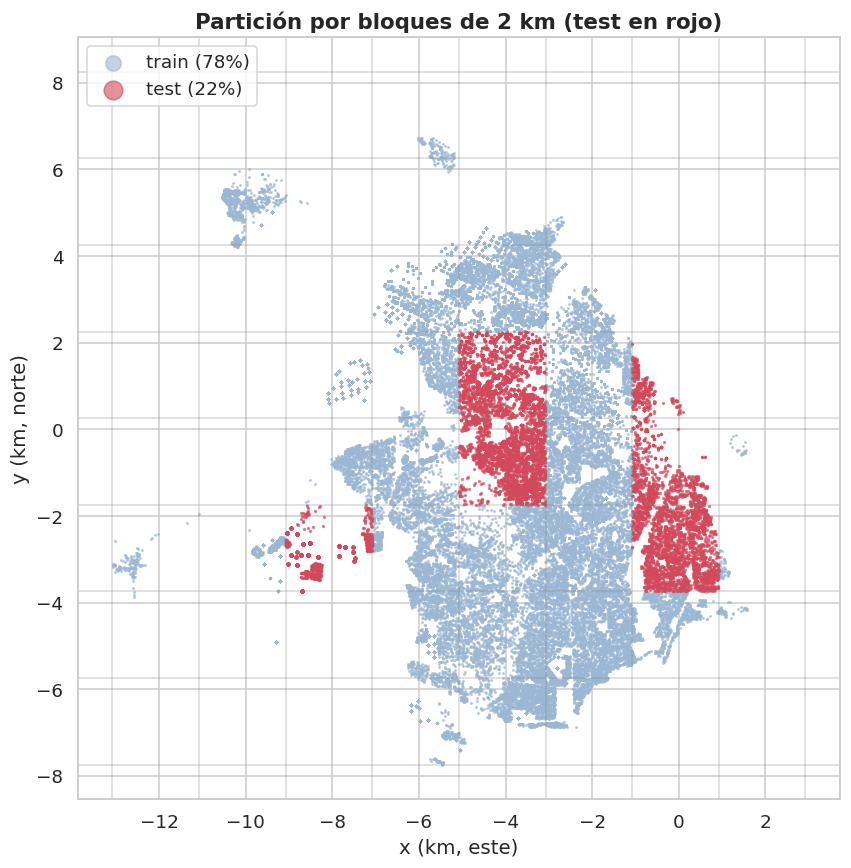

In [8]:
# Mapa de la partición: puntos de train (azul) y test (rojo) sobre la grilla de
# bloques de 2 km. Permite verificar visualmente que test son zonas compactas y
# repartidas por la ciudad, no puntos sueltos mezclados con train.
fig, ax = plt.subplots(figsize=(9, 9))
# Submuestra de hasta 60 000 puntos solo para dibujar rápido (semilla fija).
muestra = con.sample(min(60_000, len(con)), random_state=C.SEED)
# Test se dibuja después y un poco más grande para que resalte sobre train;
# la leyenda muestra el % de filas de cada conjunto calculado sobre 'con' completo.
for nombre, color, tam in [("train", "#9bb7d4", 1), ("test", "#d1495b", 1.5)]:
    s = muestra[muestra["particion"] == nombre]
    ax.scatter(s["x_km"], s["y_km"], s=tam, c=color, label=f"{nombre} ({(con.particion == nombre).mean():.0%})",
               alpha=0.6, rasterized=True)
# Líneas de la grilla: parten del mínimo de x e y, igual que asignar_bloques, para
# que coincidan con los bordes reales de los bloques (xs/ys no se usan después).
xs = np.arange(np.floor(con.x_km.min()), con.x_km.max() + C.TAM_BLOQUE_KM, C.TAM_BLOQUE_KM)
ys = np.arange(np.floor(con.y_km.min()), con.y_km.max() + C.TAM_BLOQUE_KM, C.TAM_BLOQUE_KM)
x0, y0 = con.x_km.min(), con.y_km.min()
for v in np.arange(x0, con.x_km.max() + C.TAM_BLOQUE_KM, C.TAM_BLOQUE_KM):
    ax.axvline(v, color="grey", lw=0.3)
for v in np.arange(y0, con.y_km.max() + C.TAM_BLOQUE_KM, C.TAM_BLOQUE_KM):
    ax.axhline(v, color="grey", lw=0.3)
G.ejes_mapa(ax, f"Partición por bloques de {C.TAM_BLOQUE_KM:.0f} km (test en rojo)")
ax.legend(markerscale=10, loc="upper left")   # marcadores de la leyenda agrandados
G.guardar(fig, "02_particion_mapa")
plt.show()

In [9]:
# Persistencia: se guarda el dataset de modelado con las columnas 'bloque' y
# 'particion' (parquet, o CSV si no hay motor parquet) para que los caps. 3 a 10
# lean exactamente la misma partición. Las filas sin coordenadas se guardan aparte,
# en el mismo formato, para analizar en el cap. 3 el sesgo de excluirlas.
# Las decisiones (tamaño de bloque, semilla) quedan en decisiones_eda.json con su
# motivo, para rastrear cada elección del modelado hasta el hallazgo que la justifica.
ruta = P.guardar_particion(con)
sin.to_parquet(C.CARPETA_PROCESADOS / "sin_coordenadas.parquet", index=False) \
    if ruta.suffix == ".parquet" else sin.to_csv(C.CARPETA_PROCESADOS / "sin_coordenadas.csv", index=False)
C.guardar_decision("tam_bloque_km", C.TAM_BLOQUE_KM,
                   "Bloques de 2 km: mayores que la escala de un barrio/edificio, de modo que "
                   "unidades vecinas casi idénticas no queden a ambos lados de la partición.")
C.guardar_decision("semilla", C.SEED, "Semilla única para partición, CV, muestreos y modelos.")
print(f"Guardado: {ruta}")

[decisión registrada] tam_bloque_km = 2.0
   motivo: Bloques de 2 km: mayores que la escala de un barrio/edificio, de modo que unidades vecinas casi idénticas no queden a ambos lados de la partición.
[decisión registrada] semilla = 42
   motivo: Semilla única para partición, CV, muestreos y modelos.
Guardado: datos/procesados/dataset_modelado.parquet


```{admonition} Regla para el resto del libro
:class: important
Desde aquí, **todos** los capítulos de EDA (3 a 9) cargan únicamente
`particion == "train"` con `P.cargar_particion(solo="train")`. El conjunto de
prueba solo se vuelve a abrir en el capítulo 10, una única vez, para la
evaluación final del modelo ya decidido.
```